In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("soumyakushwaha/indian-sign-language-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Prakriti\.cache\kagglehub\datasets\soumyakushwaha\indian-sign-language-dataset\versions\1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Understanding the different directories and listing the important data into the list named data

In [5]:
print(os.listdir(path))
isl_path = os.path.join(path,'ISL_Dataset')
print(os.listdir(isl_path))

['ISL_Dataset']
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z']


In [6]:
data = []
for folder in os.listdir(isl_path):  
    dataset = os.path.join(isl_path, folder)  
    if os.path.isdir(dataset):  
        for image in os.listdir(dataset):  
            image_path = os.path.join(dataset, image)  
            data.append([image_path, folder]) 


# Creating a dataframe

In [7]:
df = pd.DataFrame(data, columns=['image_path', 'isl_path'])

In [8]:
df.sample(10)

,image_path,isl_path
408,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,O
95,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,C
33,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,B
363,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,N
388,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,O
561,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,T
550,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,T
364,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,N
290,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,K
159,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,E


In [9]:
len(df)

702

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  702 non-null    object
 1   isl_path    702 non-null    object
dtypes: object(2)
memory usage: 11.1+ KB


In [11]:
df.describe()

,image_path,isl_path
count,702,702
unique,702,23
top,C:\Users\Prakriti\.cache\kagglehub\datasets\so...,E
freq,1,46


In [12]:
print("Columns in DataFrame:", df.columns)
print("Files in Directory:", os.listdir(isl_path))


Columns in DataFrame: Index(['image_path', 'isl_path'], dtype='object')
Files in Directory: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z']


In [13]:
import os
import cv2

path = r'C:\Users\Prakriti\.cache\kagglehub\datasets\soumyakushwaha\indian-sign-language-dataset\versions\1'
img_size = 60
images = []
labels = []

dataset_path = os.path.join(path, 'ISL_Dataset')

# Get the list of subfolders inside ISL_Dataset
isl_folders = os.listdir(dataset_path)  # This now correctly gets ['A', 'B', 'C', ..., 'Z']|| isl_path earlier was looping over a string but this is inlisting ofer actual folders

for folder in isl_folders:
    data_path = os.path.join(dataset_path, folder)  # Construct full path to each class folder

    # filenames = [f for f in os.listdir(data_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    filenames = []  # Create an empty list
    for f in os.listdir(data_path):  # Loop through each file in the folder
        if f.endswith(('.jpg', '.png', '.jpeg')):  # Check if file is an image
            filenames.append(f)  # Add it to the list


    for f in filenames:
        img = cv2.imread(os.path.join(data_path, f))  # Read the image
        if img is None:
            print(f"Skipping {f}, could not load image")
            continue

        img = cv2.resize(img, (img_size, img_size))  # Resize to 60x60 pixels
        images.append(img)
        labels.append(folder)  # Append folder name as label

print(f"Total images loaded: {len(images)}")
print(f"Total labels loaded: {len(labels)}")


Total images loaded: 702
Total labels loaded: 702


In [14]:
images = np.array(images)
images.shape

(702, 60, 60, 3)

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  

y_labelencoder = LabelEncoder()  
y = y_labelencoder.fit_transform(labels)
y = y.reshape(-1, 1)
print(y)

[[ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 0]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 2]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 3]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4]
 [ 4

In [16]:
one_hot_encoder = OneHotEncoder(sparse_output=False)  
y = one_hot_encoder.fit_transform(y)  
print(y)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [17]:
images = np.array(images, dtype=np.float32) / 255.0  # Normalize pixel values

In [18]:
print("Images Shape:", images.shape)
print("Labels Shape:", y.shape)


Images Shape: (702, 60, 60, 3)
Labels Shape: (702, 23)


In [19]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

images,y = shuffle(images,y, random_state=1)

train_x,test_x,train_y,test_y = train_test_split(images, y , test_size = 0.2, random_state=42)

print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(561, 60, 60, 3)
(561, 23)
(141, 60, 60, 3)
(141, 23)


In [20]:
import tensorflow as tf

num_classes = 23

n_input = 10800 #flattened image

#setting up hyperparameters
learning_rates = 0.001
training_iterations = 10
batch_size = 16
display_step = 20

In [21]:
img_size = 60
num_channels = 3

x = tf.keras.Input(shape=(img_size, img_size, num_channels), dtype=tf.float32)
y_ = tf.keras.Input(shape=(num_classes,), dtype=tf.float32)

print('Shape of input tensors:', x.shape, y_.shape)

Shape of input tensors: (None, 60, 60, 3) (None, 23)


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam  

# Define variables
img_size = 60
num_channels = 3
img_classes = 23

base_model = MobileNetV2(input_shape=(img_size, img_size, num_channels), include_top=False, weights='imagenet')
base_model.trainable = False

# Adding custom layers
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(img_classes, activation='softmax')(x)


# Creating the model
model = Model(inputs=base_model.input, outputs=output)

# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Model summary
model.summary()

C:\Users\Prakriti\AppData\Local\Temp\ipykernel_25376\1075796453.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(img_size, img_size, num_channels), include_top=False, weights='imagenet')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 60, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 30, 30,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 30, 30,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 30, 30,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 30, 30,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 30, 30,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 30, 30,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 30, 30,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 30, 30,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 31, 31,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 15, 15,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 15, 15,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 15, 15,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 15, 15,    │      2,304 │ block_1_depthwis

 Total params: 3,574,871 (13.64 MB)

 Trainable params: 1,316,887 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
history = model.fit(train_x, train_y, epochs=10, batch_size=16, validation_data=(test_x, test_y))


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.0524 - loss: 4.3681 - val_accuracy: 0.1206 - val_loss: 3.0196
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.3205 - loss: 2.4462 - val_accuracy: 0.1064 - val_loss: 3.0449
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.4498 - loss: 1.9260 - val_accuracy: 0.1844 - val_loss: 3.0831
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5552 - loss: 1.5823 - val_accuracy: 0.1418 - val_loss: 3.2161
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6490 - loss: 1.2743 - val_accuracy: 0.1418 - val_loss: 3.1252
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7534 - loss: 0.8093 - val_accuracy: 0.1560 - val_loss: 3.2891
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8292 - loss: 0.6421 - val_accuracy: 0.1844 - val_loss: 3.3424
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8465 - loss: 0.5203 - val_accuracy: 0.2057 -

In [24]:
test_loss, test_acc = model.evaluate(test_x, test_y)
print(f"Test Accuracy: {test_acc:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1878 - loss: 3.6594
Test Accuracy: 0.1844


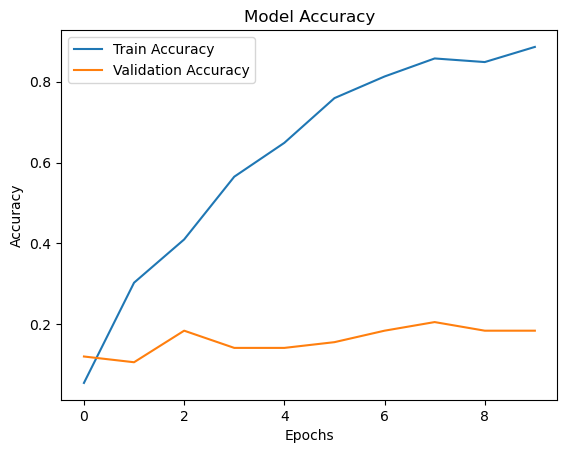

In [25]:
import matplotlib.pyplot as plt  

# Plot training & validation accuracy  
plt.plot(history.history['accuracy'], label='Train Accuracy')  
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  
plt.xlabel('Epochs')  
plt.ylabel('Accuracy')  
plt.legend()  
plt.title('Model Accuracy')  
plt.show()


In [26]:
model.save("improved_sign_language_model.h5")

In [27]:
import cv2
import numpy as np

# Open the webcam
cap = cv2.VideoCapture(0)

# Define labels corresponding to classes (A-Z)
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 
          'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z']

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Define region of interest (ROI) for hand gesture detection
    roi = frame[100:400, 100:400]
    cv2.rectangle(frame, (100, 100), (400, 400), (0, 255, 0), 2)

    # Preprocess the ROI
    img = cv2.resize(roi, (60, 60))
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)

    # Get model prediction
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    predicted_label = labels[class_index]

    # Display the prediction on the frame
    cv2.putText(frame, f'Prediction: {predicted_label}', (10, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Show the frame
    cv2.imshow("Sign Language Recognition", frame)

    # Break on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━